# K-Means on Processed EEG Data

This notebook trains and evaluates the TensorFlow `KMeansTF` model on your **processed / shuffled** EEG dataset.

- **Input**: The folder you selected via the GUI file shuffler (all `.txt` files there are now `.csv`).
- **Goal**: Reuse the best K-Means pipeline we built earlier (per-file windows, bandpass filtering, brainwave bands + temporal features, Z-score scaling, optional PCA) but pointed at the **processed data root**.

> **Note:** Update `data_root_processed` in the next cell to match the folder that contains your processed EEG files (e.g., your `Data_clean_processed` path).

In [13]:
# Imports (robust path setup so kmeans_model is found)
print("Starting Imports...")

import sys
import os
import re
import pathlib
import importlib
import numpy as np
import pandas as pd


from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from scipy.signal import butter, sosfiltfilt, welch
from scipy.stats import skew, kurtosis

# Ensure the directory containing kmeans_model.py is on sys.path
_nb_dir = pathlib.Path.cwd()
_candidates = [
    _nb_dir,                                      # e.g. repo root if kmeans_model.py is here
    _nb_dir / "prediction_k_means" / "tensorflow",  # repo-root-based path
    _nb_dir / "tensorflow",                      # if cwd is already prediction_k_means
]

_kmeans_dir = None
for cand in _candidates:
    if (cand / "kmeans_model.py").exists():
        _kmeans_dir = cand
        break

if _kmeans_dir is not None and str(_kmeans_dir) not in sys.path:
    sys.path.insert(0, str(_kmeans_dir))
else:
    print("Warning: could not automatically locate kmeans_model.py; check paths if import fails.")

print("Loading kmeans_model...")

import kmeans_model
kmeans_model = importlib.reload(kmeans_model)

print("Imports OK")

Starting Imports...
Loading kmeans_model...
Imports OK


In [14]:
# Configuration

# Set this to the folder that now holds your **processed/shuffled** EEG files.
# This folder should now contain 6 subfolders (backward, forward, landing, left, right, takeoff)
# and a single report file named "remove-8channel-Report.csv" which will be ignored.
data_root_processed = pathlib.Path("/update/with/your/path/to/processed/data") # <-- UPDATE THIS PATH

# Default sampling rate for processed files (can be changed if you ever
# export at a different Hz in the future).
default_fs = 125.0

# Directories to skip entirely (leave empty unless you have specific folders to ignore)
skip_dirs = set()

# Filenames to ignore even if they live under data_root_processed
ignore_files = {"remove-8channel-Report.csv"}

# K-Means / PCA settings
use_pca = False
pca_components = 50
n_clusters = 300
max_iter = 1000
tol = 1e-6
random_state = 42

print("Using processed data root:", data_root_processed)
print("Configuration Done!")

Using processed data root: /update/with/your/path/to/processed/data
Configuration Done!


In [15]:
# Load all processed EEG files and attach a per-file sampling rate.

core_dir = pathlib.Path(data_root_processed)
assert core_dir.exists(), f"Processed data root does not exist: {core_dir}"

dfs = []
fs_values = []

# We know the processed root contains exactly these 6 label folders, so
# we can iterate them directly instead of doing a full recursive walk.
expected_labels = ["backward", "forward", "landing", "left", "right", "takeoff"]

for label_dir in core_dir.iterdir():
    if not label_dir.is_dir():
        continue
    if label_dir.name not in expected_labels:
        continue

    for item in label_dir.glob("*.csv"):
        # Skip known non‑data report file(s)
        if item.name in ignore_files:
            continue

        try:
            # Processed CSV files from the GUI pipeline currently use a fixed sampling rate
            # but we leave this configurable via `default_fs` in case you change it later.
            file_fs = float(default_fs)

            # CSV produced by the shuffler: already stripped of comment lines, header row is on line 1
            df = pd.read_csv(item, sep=",", on_bad_lines="skip")

            if df.empty or df.shape[1] < 2:
                continue

            df["src_filename"] = str(item)
            df["fs"] = file_fs
            dfs.append(df)
            fs_values.append(file_fs)
        except Exception as e:
            print(f"Failed to read {item}: {e}")

print(f"Read {len(dfs)} files from processed data root")

eeg_data = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
print("Combined shape:", eeg_data.shape)

if fs_values:
    fs_series = pd.Series(fs_values)
    print("Per-file sample rates (Hz):")
    print(fs_series.value_counts().sort_index())

print("All EEG Files Loaded!")

AssertionError: Processed data root does not exist: /update/with/your/path/to/processed/data

In [ ]:
# Derive labels directly from folder names under the processed root.

assert not eeg_data.empty, "No data loaded. Check data_root_processed points at your processed folder."

expected_labels = {"backward", "forward", "landing", "left", "right", "takeoff"}

src_paths = eeg_data["src_filename"].astype(str)
labels = []
for p in src_paths:
    parts = pathlib.Path(p).parts
    # Find the first part that matches one of the expected label folder names
    lbl = ""
    for part in parts:
        pl = part.lower()
        if pl in expected_labels:
            lbl = pl
            break
    labels.append(lbl)

eeg_data["label_txt"] = pd.Series(labels, index=eeg_data.index).astype(str)

print(eeg_data.groupby(["label_txt"])["src_filename"].count())
print("Labeling Complete!")

label_txt
backward    279619
forward     272609
landing     299873
left        297775
right       297856
takeoff     159004
Name: src_filename, dtype: int64
Labeling Complete!


In [ ]:
# Optional: inspect per-channel EEG noise to help decide which channels to drop.

# We compute simple statistics per EXG channel across the entire processed dataset.
# You can use this table to decide which channels (if any) to treat as "noisy".

numeric_cols_all = eeg_data.select_dtypes(include=[np.number]).columns
# Heuristic: EEG channels are those whose column name contains "EXG".
eeg_cols_all = [c for c in numeric_cols_all if "EXG" in c]

channel_stats = pd.DataFrame(index=eeg_cols_all)
channel_stats["std"] = eeg_data[eeg_cols_all].std()
channel_stats["median_abs"] = eeg_data[eeg_cols_all].median().abs()
channel_stats["max_abs"] = eeg_data[eeg_cols_all].abs().max()

channel_stats = channel_stats.sort_values("std", ascending=False)

print("Top EEG channels by standard deviation (potentially noisy):")
display(channel_stats.head(20))

# Automatically identify channels hitting the OpenBCI saturation rail (187,500 uV)
# plus the ones we manually identified as extreme.
railed_channels = channel_stats[channel_stats["max_abs"] >= 187500].index.tolist()

# Combine manual drops with auto-detected railed channels
noisy_channels = list(set(railed_channels))

print(f"Channels identified for dropping: {noisy_channels}")


Top EEG channels by standard deviation (potentially noisy):


,std,median_abs,max_abs
EXG Channel 11,499744.489300,10313.519575,2.448264e+06
EXG Channel 15,82045.649955,25919.976940,1.875000e+05
EXG Channel 2,63455.443731,24692.352079,1.875000e+05
EXG Channel 14,55536.999002,17533.043627,1.875000e+05
EXG Channel 3,48169.076361,12462.148066,1.875000e+05
EXG Channel 5,45588.819036,19.781294,1.875000e+05
EXG Channel 13,40641.456301,15027.658943,1.875000e+05
EXG Channel 10,31918.038876,19851.299507,1.875000e+05
EXG Channel 0,29170.751701,11995.913028,1.777953e+05
EXG Channel 7,28461.178831,2971.843239,1.508448e+05


Channels identified for dropping: [' EXG Channel 2', ' EXG Channel 5', ' EXG Channel 13', ' EXG Channel 11', ' EXG Channel 3', ' EXG Channel 14', ' EXG Channel 10', ' EXG Channel 15']


In [ ]:
# Build feature matrix X and label vector y from processed data

df = eeg_data.copy()
# Keep all sampling rates; `fs` is used later on a per-file basis.
df = df[df["label_txt"].astype(str).str.len() > 0]

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Drop obvious non-EEG columns but keep accelerometer; do not use sampling rate as a feature
drop_keywords = ["Sample", "Timestamp", "Marker", "Not Used", "Analog", "Digital", "Other"]
drop_cols = [c for c in num_cols if any(key in c for key in drop_keywords)]

if "fs" in num_cols:
    drop_cols.append("fs")

# src_filename is non-numeric, but guard just in case
if "src_filename" in num_cols:
    drop_cols.append("src_filename")

drop_cols = sorted(set(drop_cols))
feature_cols = [c for c in num_cols if c not in drop_cols]

feat = df[feature_cols].copy()
feat = feat.replace([np.inf, -np.inf], np.nan)
feat = feat.dropna(axis=1, how="all")

med = feat.median(numeric_only=True)
feat = feat.fillna(med)

std = feat.std(numeric_only=True)
keep = std[std > 0].index.tolist()
if len(keep) == 0:
    keep = feature_cols
    print("Warning: no columns had std > 0; using all numeric columns.")

# Drop any channels explicitly marked as noisy in the previous cell
if "noisy_channels" in globals():
    for ch in noisy_channels:
        if ch in keep:
            keep.remove(ch)
            print(f"Dropped noisy channel: {ch}")

# # Drop accelerometer channels (EEG only for K-Means)
# keep = [c for c in keep if "Accel" not in c]

feat = feat[keep]
X = feat.to_numpy(dtype=np.float32)

y_cat = df["label_txt"].astype("category")
y = y_cat.cat.codes.to_numpy(dtype=np.int32)
label_names = list(y_cat.cat.categories)

# Store numeric labels for use in per-file windowing
df["y_code"] = y

print("X shape:", X.shape, "classes:", len(label_names))
print(f"Features being used for K-Means: {keep}")
print("Feature Extraction Complete!")

Dropped noisy channel:  EXG Channel 2
Dropped noisy channel:  EXG Channel 5
Dropped noisy channel:  EXG Channel 13
Dropped noisy channel:  EXG Channel 11
Dropped noisy channel:  EXG Channel 3
Dropped noisy channel:  EXG Channel 14
Dropped noisy channel:  EXG Channel 10
Dropped noisy channel:  EXG Channel 15
X shape: (1606736, 11) classes: 6
Features being used for K-Means: [' EXG Channel 0', ' EXG Channel 1', ' EXG Channel 4', ' EXG Channel 6', ' EXG Channel 7', ' EXG Channel 8', ' EXG Channel 9', ' EXG Channel 12', ' Accel Channel 0', ' Accel Channel 1', ' Accel Channel 2']
Feature Extraction Complete!


In [ ]:
# Feature extraction: per-file 1-second windows, bandpass 1–50 Hz, brainwave bands + temporal texture


X_psd = []
y_psd = []

# Split EEG vs accelerometer using the chosen keep list
eeg_idx = [i for i, c in enumerate(keep) if "Accel" not in c]
accel_idx = [i for i, c in enumerate(keep) if "Accel" in c]

print(f"Extracting features from {len(eeg_idx)} EEG channels and {len(accel_idx)} Accel channels...")

required_cols = keep + ["y_code", "fs", "src_filename"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns for PSD extraction: {missing_cols}")

work_df = df[required_cols].copy()

for fname, g in work_df.groupby("src_filename", sort=False):
    file_fs = float(g["fs"].iloc[0]) if "fs" in g.columns else 125.0
    if file_fs <= 0:
        file_fs = 125.0

    # 1. Separate and Clean the entire file first
    # This prevents edge artifacts from filtering small windows
    raw_data = g[keep].to_numpy(dtype=np.float32)
    y_labels = g["y_code"].to_numpy(dtype=np.int32)
    
    # Filter only the EEG portion
    eeg_filtered = kmeans_model.apply_bandpass_to_signal(raw_data[:, eeg_idx], file_fs)
    accel_raw = raw_data[:, accel_idx]
    
    # 2. Windowing
    win_size = int(file_fs)
    step = max(1, win_size // 2)
    
    if eeg_filtered.shape[0] < win_size:
        continue

    for start in range(0, eeg_filtered.shape[0] - win_size, step):
        # Slice windows
        win_eeg = eeg_filtered[start : start + win_size, :]
        win_accel = accel_raw[start : start + win_size, :]

        # Extract features using the .py helper
        row_feats = kmeans_model.extract_window_features(win_eeg, win_accel, file_fs)
        X_psd.append(row_feats)
        y_psd.append(y_labels[start])


X_psd = np.array(X_psd, dtype=np.float32)
y_psd = np.array(y_psd, dtype=np.int32)

print(f"Built {X_psd.shape[0]} windows with {X_psd.shape[1]} features each.")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_psd, y_psd, test_size=0.2, random_state=42, stratify=y_psd
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train/test split complete!")

Extracting features from 8 EEG channels and 3 Accel channels...
Built 23974 windows with 35 features each.
Train shape: (19179, 35) Test shape: (4795, 35)
Train/test split complete!


In [ ]:
# Rescale features (Z‑score) and optionally apply PCA

# For relative power features we **skip log10**; they are already normalized.
X_train_proc = X_train
X_test_proc = X_test

mu = np.nanmean(X_train_proc, axis=0)
sd = np.nanstd(X_train_proc, axis=0)

# Avoid divide‑by‑zero and NaNs
sd[sd == 0] = 1.0
mu[np.isnan(mu)] = 0.0

X_train_z = (X_train_proc - mu) / sd
X_test_z = (X_test_proc - mu) / sd

X_train_z = np.nan_to_num(X_train_z)
X_test_z = np.nan_to_num(X_test_z)

print(f"Rescaling complete. Any NaNs left? {np.isnan(X_train_z).any()}")
print("Training shape after scaling:", X_train_z.shape)

# PCA (optional)
if use_pca:
    pca = PCA(n_components=pca_components, random_state=42)
    X_train_final = pca.fit_transform(X_train_z)
    X_test_final = pca.transform(X_test_z)
    print(
        f"PCA complete. Retained {np.sum(pca.explained_variance_ratio_) * 100:.2f}% of variance; "
        f"feature dim = {X_train_final.shape[1]}"
    )
else:
    pca = None
    X_train_final = X_train_z
    X_test_final = X_test_z
    print("PCA disabled; using raw scaled features.")

Rescaling complete. Any NaNs left? False
Training shape after scaling: (19179, 35)
PCA disabled; using raw scaled features.


### Optional: elbow plot (inertia vs. *k*)

This fits standard **k-means** on the **same scaled training features** (`X_train_final`) for a range of cluster counts and plots **within-cluster sum of squares (inertia)**. A visible “elbow” suggests a reasonable *k*; it is only a heuristic.

For speed, training rows may be **subsampled** (see `elbow_max_samples` in the next cell). Uses `sklearn.cluster.KMeans` (same objective as your `KMeansTF` fit). After choosing *k*, set `n_clusters` in the **Configuration** cell and re-run from there.

In [19]:
# Elbow plot: inertia vs k (run after scaling so X_train_final exists; before or after main KMeansTF training)

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

elbow_k_min = 2
elbow_k_max = 40
elbow_max_samples = 12000  # set None to use every training window (slower)
elbow_random_state = random_state

_kvals = list(range(elbow_k_min, elbow_k_max + 1))
_Xe = X_train_final
if elbow_max_samples is not None and _Xe.shape[0] > elbow_max_samples:
    _rs = np.random.RandomState(elbow_random_state)
    _idx = _rs.choice(_Xe.shape[0], size=elbow_max_samples, replace=False)
    _Xe = _Xe[_idx]
    print(f"Elbow: using {_Xe.shape[0]} training rows (subsampled).")
else:
    print(f"Elbow: using all {_Xe.shape[0]} training rows.")

_inertias = []
for _k in _kvals:
    _km = KMeans(
        n_clusters=_k,
        random_state=elbow_random_state,
        n_init=10,
        max_iter=300,
    )
    _km.fit(_Xe)
    _inertias.append(_km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(_kvals, _inertias, "o-", color="steelblue", markersize=5, linewidth=1.2)
ax.set_xlabel("Number of clusters $k$")
ax.set_ylabel("Inertia (within-cluster sum of squared distances)")
ax.set_title("Elbow plot for k-means (scaled training features)")
ax.grid(True, alpha=0.35)
if elbow_k_min <= n_clusters <= elbow_k_max:
    ax.axvline(n_clusters, color="coral", linestyle="--", linewidth=1.5, label=f"current n_clusters={n_clusters}")
    ax.legend(loc="best")
plt.tight_layout()
plt.show()


Elbow: using 12000 training rows (subsampled).


KeyboardInterrupt: 

In [ ]:
# Train KMeansTF on processed features and evaluate

model = kmeans_model.KMeansTF(
    n_clusters=n_clusters,
    max_iter=max_iter,
    tol=tol,
    random_state=random_state,
)

print(f"Starting KMeansTF training on {X_train_final.shape[1]} features...")
model.fit(X_train_final, y_train)

print(f"Inertia (tightness): {model.inertia_:.2f}")
print("Cluster-to-label mapping (processed data):")
for k, v in sorted(model.cluster_to_label_map_.items()):
    print(f"  cluster {k} -> {label_names[v]} (class {v})")

print("Predicting on test set...")
y_pred = model.predict(X_test_final)

acc = accuracy_score(y_test, y_pred)
print(f"\nOverall Accuracy (processed data): {acc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_names, zero_division=0))

Starting KMeansTF training on 35 features...


2026-03-09 16:18:13.865656: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Inertia (tightness): 99962.00
Cluster-to-label mapping (processed data):
  cluster 0 -> backward (class 0)
  cluster 1 -> left (class 3)
  cluster 2 -> right (class 4)
  cluster 3 -> landing (class 2)
  cluster 4 -> backward (class 0)
  cluster 5 -> left (class 3)
  cluster 6 -> forward (class 1)
  cluster 7 -> forward (class 1)
  cluster 8 -> backward (class 0)
  cluster 9 -> backward (class 0)
  cluster 10 -> landing (class 2)
  cluster 11 -> left (class 3)
  cluster 12 -> right (class 4)
  cluster 13 -> right (class 4)
  cluster 14 -> landing (class 2)
  cluster 15 -> landing (class 2)
  cluster 16 -> forward (class 1)
  cluster 17 -> landing (class 2)
  cluster 18 -> left (class 3)
  cluster 19 -> right (class 4)
  cluster 20 -> right (class 4)
  cluster 21 -> left (class 3)
  cluster 22 -> left (class 3)
  cluster 23 -> right (class 4)
  cluster 24 -> forward (class 1)
  cluster 25 -> landing (class 2)
  cluster 26 -> landing (class 2)
  cluster 27 -> backward (class 0)
  cluster 

### Figures for publication

The next cell generates **PCA 2D scatter plots** (true vs predicted class), a **confusion matrix** heatmap, **per-class F1** bars, and **training cluster size** distribution. Later cells add **t-SNE**, **LDA**, and a **Hjorth mobility–complexity** scatter tied to the same **cluster→label** rule. Run **after** the training/evaluation cell so `model`, `X_train_final`, `X_test_final`, `y_train`, `y_test`, and `y_pred` exist.

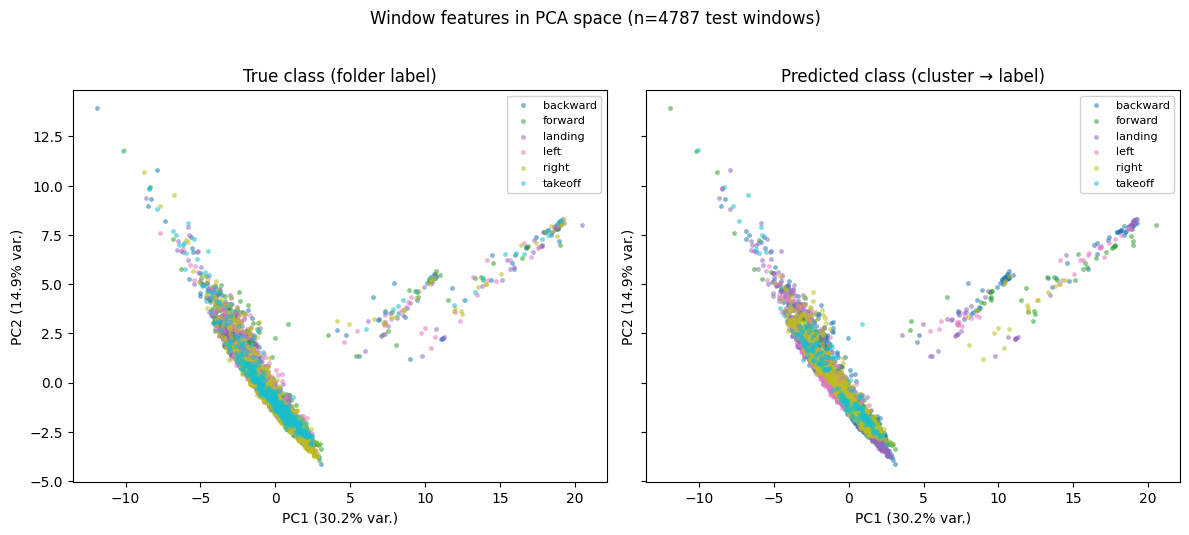

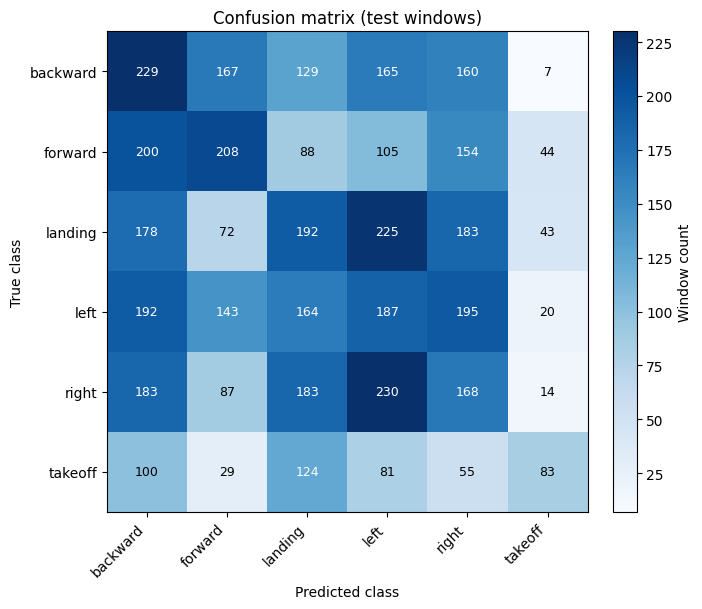

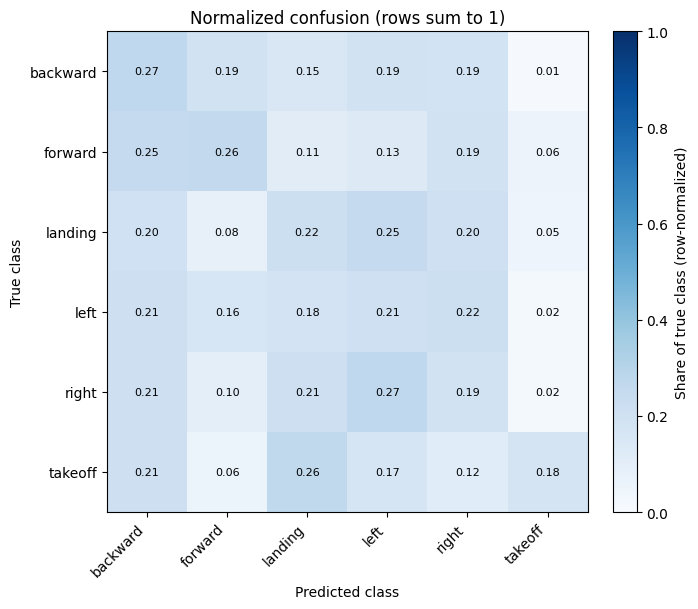

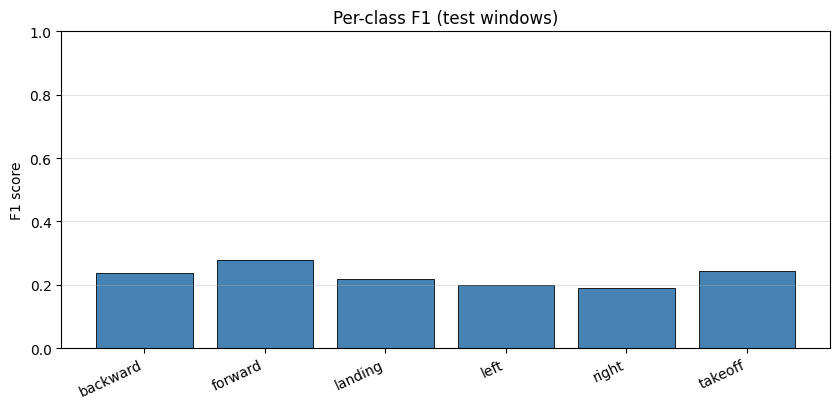

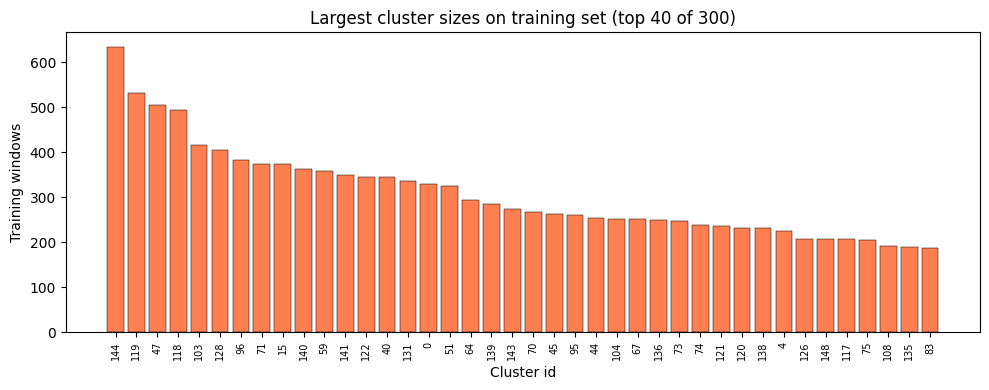

In [16]:
# Publication-style figures: PCA embedding, confusion matrix, F1 by class, cluster sizes
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score

# --- Subsample test windows for scatter (keeps plots readable) ---
_rng = np.random.RandomState(random_state)
_n_test = X_test_final.shape[0]
_max_scatter = 8000
_sub_idx = _rng.choice(_n_test, size=min(_max_scatter, _n_test), replace=False)

# 2D PCA fit on training features only; project train + test
_pca2 = PCA(n_components=2, random_state=random_state)
_pca2.fit(X_train_final)
_xy_test = _pca2.transform(X_test_final)
_xy_sub = _xy_test[_sub_idx]
_y_true_sub = y_test[_sub_idx]
_y_pred_sub = y_pred[_sub_idx]

_n_classes = len(label_names)
_colors = plt.cm.tab10(np.linspace(0, 1, max(_n_classes, 3)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharex=True, sharey=True)
for ax, y_vec, title in zip(
    axes,
    [_y_true_sub, _y_pred_sub],
    ["True class (folder label)", "Predicted class (cluster → label)"],
):
    for c in range(_n_classes):
        m = y_vec == c
        if not np.any(m):
            continue
        ax.scatter(
            _xy_sub[m, 0],
            _xy_sub[m, 1],
            s=12,
            alpha=0.55,
            c=[_colors[c]],
            label=label_names[c],
            linewidths=0,
        )
    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({100 * _pca2.explained_variance_ratio_[0]:.1f}% var.)")
    ax.set_ylabel(f"PC2 ({100 * _pca2.explained_variance_ratio_[1]:.1f}% var.)")
    ax.legend(loc="best", fontsize=8, framealpha=0.9)
axes[0].set_aspect("auto")
fig.suptitle(
    f"Window features in PCA space (n={len(_sub_idx)} test windows)",
    fontsize=12,
    y=1.02,
)
plt.tight_layout()
plt.show()

# --- Confusion matrix (counts) ---
_cm = confusion_matrix(y_test, y_pred, labels=np.arange(_n_classes))
fig, ax = plt.subplots(figsize=(7.5, 6.2))
_im = ax.imshow(_cm, cmap="Blues", interpolation="nearest")
ax.set_xticks(np.arange(_n_classes))
ax.set_yticks(np.arange(_n_classes))
ax.set_xticklabels(label_names, rotation=45, ha="right")
ax.set_yticklabels(label_names)
ax.set_ylabel("True class")
ax.set_xlabel("Predicted class")
plt.colorbar(_im, ax=ax, fraction=0.046, pad=0.04, label="Window count")
_thresh = _cm.max() / 2.0 if _cm.size else 0
for i in range(_n_classes):
    for j in range(_n_classes):
        ax.text(
            j,
            i,
            int(_cm[i, j]),
            ha="center",
            va="center",
            color="white" if _cm[i, j] > _thresh else "black",
            fontsize=9,
        )
ax.set_title("Confusion matrix (test windows)")
plt.tight_layout()
plt.show()

# --- Normalized confusion (row = recall per true class) ---
_row = _cm.sum(axis=1, keepdims=True)
_cm_norm = np.divide(_cm, _row, out=np.zeros_like(_cm, dtype=float), where=_row > 0)
fig, ax = plt.subplots(figsize=(7.5, 6.2))
_im2 = ax.imshow(_cm_norm, cmap="Blues", vmin=0, vmax=1, interpolation="nearest")
ax.set_xticks(np.arange(_n_classes))
ax.set_yticks(np.arange(_n_classes))
ax.set_xticklabels(label_names, rotation=45, ha="right")
ax.set_yticklabels(label_names)
ax.set_ylabel("True class")
ax.set_xlabel("Predicted class")
plt.colorbar(_im2, ax=ax, fraction=0.046, pad=0.04, label="Share of true class (row-normalized)")
for i in range(_n_classes):
    for j in range(_n_classes):
        ax.text(j, i, f"{_cm_norm[i, j]:.2f}", ha="center", va="center", color="black", fontsize=8)
ax.set_title("Normalized confusion (rows sum to 1)")
plt.tight_layout()
plt.show()

# --- Per-class F1 ---
_f1 = f1_score(y_test, y_pred, average=None, zero_division=0, labels=np.arange(_n_classes))
fig, ax = plt.subplots(figsize=(8.5, 4.2))
x = np.arange(_n_classes)
ax.bar(x, _f1, color="steelblue", edgecolor="black", linewidth=0.6)
ax.set_xticks(x)
ax.set_xticklabels(label_names, rotation=25, ha="right")
ax.set_ylabel("F1 score")
ax.set_ylim(0, 1)
ax.set_title("Per-class F1 (test windows)")
ax.grid(axis="y", alpha=0.35)
plt.tight_layout()
plt.show()

# --- Largest training clusters by window count (structure of k-means partitions) ---
_train_lab = model.labels_
_u, _counts = np.unique(_train_lab, return_counts=True)
_order = np.argsort(-_counts)[: min(40, len(_u))]
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    np.arange(len(_order)),
    _counts[_order],
    color="coral",
    edgecolor="black",
    linewidth=0.35,
)
ax.set_xticks(np.arange(len(_order)))
ax.set_xticklabels([str(_u[i]) for i in _order], rotation=90, fontsize=7)
ax.set_xlabel("Cluster id")
ax.set_ylabel("Training windows")
ax.set_title(f"Largest cluster sizes on training set (top {len(_order)} of {n_clusters})")
plt.tight_layout()
plt.show()


### t-SNE and LDA embeddings

**t-SNE** gives a nonlinear 2D view that often reveals local grouping; distances between distant points are not interpretable. It is fit on a **random subsample of test windows** (for speed).

**LDA (Linear Discriminant Analysis)** finds directions that **separate the six movement classes** using labels; it is **fit on training data only**, then **test** windows are projected—useful to see how separable classes are in a supervised sense (complement to unsupervised PCA/t-SNE).

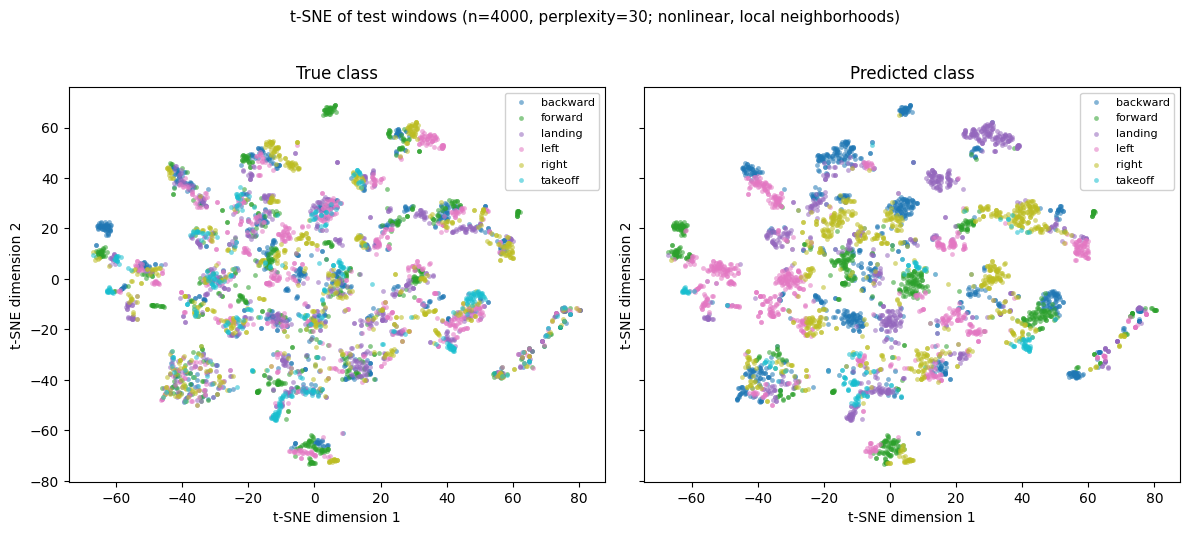

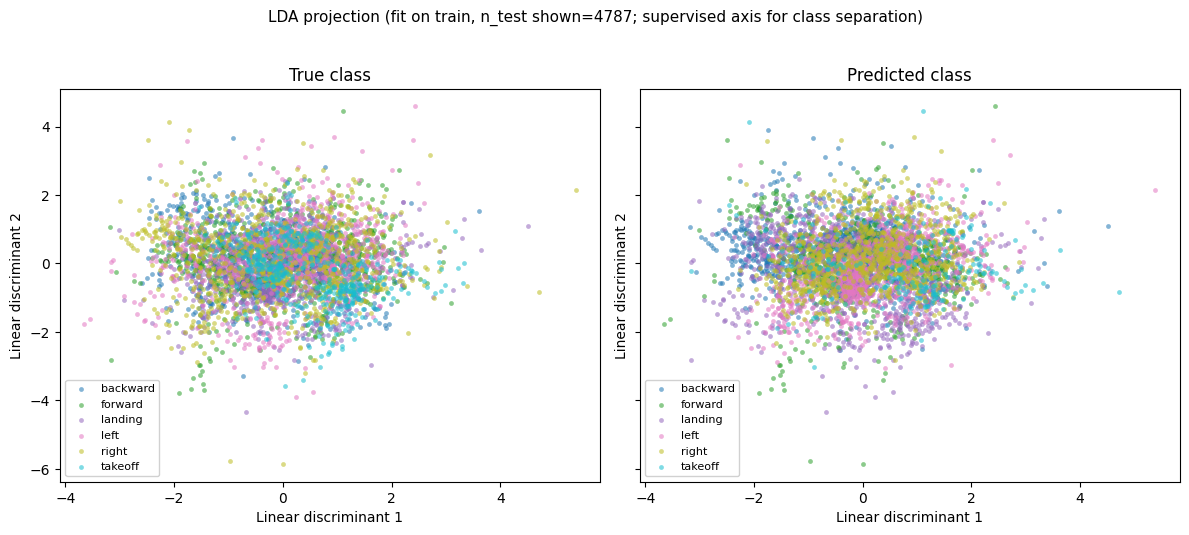

In [18]:
# t-SNE (unsupervised) + LDA (supervised) 2D views — run after the training/evaluation cell
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

_embed_rng = np.random.RandomState(random_state)
_n_classes = len(label_names)
_colors = plt.cm.tab10(np.linspace(0, 1, max(_n_classes, 3)))

# --- t-SNE: embed a subsample of test windows only (no training points in the fit) ---
_n_tsne = min(4000, X_test_final.shape[0])
_tsne_idx = _embed_rng.choice(X_test_final.shape[0], size=_n_tsne, replace=False)
_X_tsne = X_test_final[_tsne_idx]
_y_tsne_true = y_test[_tsne_idx]
_y_tsne_pred = y_pred[_tsne_idx]
_perp = int(min(30, max(5, (_n_tsne - 1) // 3)))

_tsne = TSNE(
    n_components=2,
    random_state=random_state,
    perplexity=_perp,
    max_iter=1000,
    init="pca",
    learning_rate="auto",
)
_xy_tsne = _tsne.fit_transform(_X_tsne)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharex=True, sharey=True)
for ax, y_vec, title in zip(
    axes,
    [_y_tsne_true, _y_tsne_pred],
    ["True class", "Predicted class"],
):
    for c in range(_n_classes):
        m = y_vec == c
        if not np.any(m):
            continue
        ax.scatter(
            _xy_tsne[m, 0],
            _xy_tsne[m, 1],
            s=12,
            alpha=0.55,
            c=[_colors[c]],
            label=label_names[c],
            linewidths=0,
        )
    ax.set_title(title)
    ax.set_xlabel("t-SNE dimension 1")
    ax.set_ylabel("t-SNE dimension 2")
    ax.legend(loc="best", fontsize=8, framealpha=0.9)
fig.suptitle(
    f"t-SNE of test windows (n={_n_tsne}, perplexity={_perp}; nonlinear, local neighborhoods)",
    fontsize=11,
    y=1.02,
)
plt.tight_layout()
plt.show()

# --- LDA: fit on train, project test (max 2 components for 6 classes) ---
_lda_k = min(2, _n_classes - 1)
_lda = LinearDiscriminantAnalysis(n_components=_lda_k)
_lda.fit(X_train_final, y_train)
_xy_lda_full = _lda.transform(X_test_final)

_max_lda = min(8000, _xy_lda_full.shape[0])
_lda_plot_idx = _embed_rng.choice(_xy_lda_full.shape[0], size=_max_lda, replace=False)
_xy_lda = _xy_lda_full[_lda_plot_idx]
_y_lda_true = y_test[_lda_plot_idx]
_y_lda_pred = y_pred[_lda_plot_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharex=True, sharey=True)
if _lda_k == 1:
    # Two-class edge case: 1D discriminant — strip plot
    for ax, y_vec, title in zip(axes, [_y_lda_true, _y_lda_pred], ["True class", "Predicted class"]):
        for c in range(_n_classes):
            m = y_vec == c
            if not np.any(m):
                continue
            ax.scatter(
                _xy_lda[m, 0],
                np.zeros(np.sum(m)),
                s=14,
                alpha=0.55,
                c=[_colors[c]],
                label=label_names[c],
                linewidths=0,
            )
        ax.set_yticks([])
        ax.set_xlabel("LD1")
        ax.set_title(title)
        ax.legend(loc="best", fontsize=8, framealpha=0.9)
else:
    for ax, y_vec, title in zip(axes, [_y_lda_true, _y_lda_pred], ["True class", "Predicted class"]):
        for c in range(_n_classes):
            m = y_vec == c
            if not np.any(m):
                continue
            ax.scatter(
                _xy_lda[m, 0],
                _xy_lda[m, 1],
                s=12,
                alpha=0.55,
                c=[_colors[c]],
                label=label_names[c],
                linewidths=0,
            )
        ax.set_xlabel("Linear discriminant 1")
        ax.set_ylabel("Linear discriminant 2")
        ax.set_title(title)
        ax.legend(loc="best", fontsize=8, framealpha=0.9)

fig.suptitle(
    f"LDA projection (fit on train, n_test shown={_max_lda}; supervised axis for class separation)",
    fontsize=11,
    y=1.02,
)
plt.tight_layout()
plt.show()


### Hjorth plane vs cluster→label assignments

The next figure builds **one row per EXG channel** in `keep`: **raw** (unscaled) **Hjorth mobility** vs **complexity** as **X** and **Y**, with three columns (true class, predicted class from the map, correct vs wrong). Assignment is still **nearest center** in **scaled** `X_test_final`, then **cluster → class** via `cluster_to_label_map_` (same as inference).


In [ ]:
# Hjorth mobility (x) vs complexity (y) for every EXG channel — true / mapped-predicted / errors
# Requires: training cell run (model, X_test, X_test_final, y_test, y_pred, eeg_idx, keep, accel_idx)

import matplotlib.pyplot as plt

_n_eeg = len(eeg_idx)
_feat_per_eeg = 4  # mobility, complexity, skew, kurtosis
if X_test.shape[1] != _n_eeg * _feat_per_eeg + len(accel_idx):
    raise ValueError(
        f"Expected {_n_eeg * _feat_per_eeg + len(accel_idx)} features, got {X_test.shape[1]}"
    )

_cc = np.asarray(model.cluster_centers_, dtype=np.float64)
_dist = np.sum((X_test_final[:, np.newaxis, :] - _cc[np.newaxis, :, :]) ** 2, axis=2)
_cluster_id = np.argmin(_dist, axis=1).astype(np.int32)
_y_pred_from_clusters = np.array(
    [model.cluster_to_label_map_[int(k)] for k in _cluster_id], dtype=np.int32
)
if not np.array_equal(_y_pred_from_clusters, y_pred):
    print("Note: recomputed mapped labels differ from y_pred; using recomputed for plot.")

_sub_n = min(8000, X_test.shape[0])
_rs = np.random.RandomState(random_state)
_sub = _rs.choice(X_test.shape[0], size=_sub_n, replace=False)

_yt = y_test[_sub]
_yp = _y_pred_from_clusters[_sub]

_n_classes = len(label_names)
_colors = plt.cm.tab10(np.linspace(0, 1, max(_n_classes, 3)))

_row_h = max(2.8, 14 / max(_n_eeg, 1))
fig, axes = plt.subplots(_n_eeg, 3, figsize=(14, _row_h * _n_eeg), squeeze=False)

for _row in range(_n_eeg):
    _i_mob = _row * _feat_per_eeg + 0
    _i_comp = _row * _feat_per_eeg + 1
    _ch_label = str(keep[eeg_idx[_row]]).strip()

    _xm = X_test[_sub, _i_mob]
    _yco = X_test[_sub, _i_comp]

    ax0, ax1, ax2 = axes[_row, 0], axes[_row, 1], axes[_row, 2]

    for c in range(_n_classes):
        m = _yt == c
        if np.any(m):
            ax0.scatter(
                _xm[m], _yco[m], s=8, alpha=0.55, c=[_colors[c]], label=label_names[c], linewidths=0
            )
    ax0.set_ylabel(f"Complexity\n{_ch_label[:28]}", fontsize=8)
    ax0.set_xlabel("Mobility", fontsize=8)
    ax0.set_title("True class" if _row == 0 else "", fontsize=9)
    ax0.grid(True, alpha=0.3)
    if _row == 0:
        ax0.legend(loc="best", fontsize=6, framealpha=0.9)

    for c in range(_n_classes):
        m = _yp == c
        if np.any(m):
            ax1.scatter(
                _xm[m], _yco[m], s=8, alpha=0.55, c=[_colors[c]], label=label_names[c], linewidths=0
            )
    ax1.set_xlabel("Mobility", fontsize=8)
    ax1.set_title(
        "Predicted (center → map)" if _row == 0 else "", fontsize=9
    )
    ax1.grid(True, alpha=0.3)
    if _row == 0:
        ax1.legend(loc="best", fontsize=6, framealpha=0.9)

    _ok = _yt == _yp
    ax2.scatter(
        _xm[_ok], _yco[_ok], s=6, c="0.75", alpha=0.45, label="Correct", linewidths=0
    )
    ax2.scatter(
        _xm[~_ok], _yco[~_ok], s=12, c="crimson", alpha=0.65, label="Wrong", linewidths=0
    )
    ax2.set_xlabel("Mobility", fontsize=8)
    ax2.set_title("Correct vs wrong" if _row == 0 else "", fontsize=9)
    ax2.legend(loc="best", fontsize=6)
    ax2.grid(True, alpha=0.3)

fig.suptitle(
    f"Hjorth plane per EXG channel (test n={_sub_n}); assignment = nearest center in scaled space → cluster→label map",
    fontsize=11,
    y=1.01,
)
plt.tight_layout()
plt.show()


In [10]:
# Save the trained KMeansTF model + preprocessing metadata for processed data

meta = {
    "mu": mu.astype(np.float32),
    "sd": sd.astype(np.float32),
    "label_names": label_names,
    "n_eeg": len([c for c in keep if "EXG" in c]),
    "n_accel": len([c for c in keep if "Accel" in c]),
    "n_clusters": n_clusters,
    "use_pca": use_pca,
    "pca": pca,
}

out_path = "kmeans_processed_CLEAN.pth"
kmeans_model.save_model(out_path, model, meta)

print(f"Model for PROCESSED data saved to {out_path}")

Model for PROCESSED data saved to kmeans_processed_CLEAN.pth
